In [57]:
# ---- importing neseccary libraies ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# ---- print dataframe ----
df = pd.read_csv('../Data/Customer-Churn.csv')
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [59]:
print(f"Shape : {df.shape}")
print(f"Dataset Info : {df.info()}")

Shape : (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

In [60]:
print("Missing Values")
print(df.isnull().sum())
print(f"Duplicates : {df.duplicated().sum()}")

Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Duplicates : 0


In [61]:
# ---- Churn Distributon ----
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [62]:
print("Unique Values")
print(f"Gender : {df['gender'].unique()}")
print(f"Tenure Range - Min : {df['tenure'].min()} Max : {df['tenure'].max()}")
print(f"Multiple Lines : {df['MultipleLines'].unique()}")
print(f"Internet Services : {df['InternetService'].unique()}")
print(f"Online Security : {df['OnlineSecurity'].unique()}")
print(f"Online Backup : {df['OnlineBackup'].unique()}")
print(f"Contract : {df['Contract'].unique()}")
print(f"Payment Method : {df['PaymentMethod'].unique()}")

Unique Values
Gender : ['Female' 'Male']
Tenure Range - Min : 0 Max : 72
Multiple Lines : ['No phone service' 'No' 'Yes']
Internet Services : ['DSL' 'Fiber optic' 'No']
Online Security : ['No' 'Yes' 'No internet service']
Online Backup : ['Yes' 'No' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
Payment Method : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [63]:
# ---- Convert churn to numeric ----
df['churn_flag'] = df['Churn'].map({'Yes':1 , 'No' : 0})
print("Churn Distribution")
print(df['churn_flag'].value_counts())
print(f"Churn Rate : {round(df['churn_flag'].mean() * 100 , 2)} %")

Churn Distribution
churn_flag
0    5174
1    1869
Name: count, dtype: int64
Churn Rate : 26.54 %


In [64]:
def tenure_groups(tenure):
    if tenure <= 12:
        return '0-12 Months'
    elif tenure <= 24:
        return '13-24 Months'
    elif tenure <= 36:
        return '25-36 Months'
    elif tenure <= 48:
        return '37-48 Months'
    elif tenure <= 60:
        return '49-60 Months'
    else:
        return '61-72 Months' 
    
df['tenure_groups'] = df['tenure'].apply(tenure_groups)
print(f"Tenure Groups : {df['tenure_groups'].value_counts()}")

Tenure Groups : tenure_groups
0-12 Months     2186
61-72 Months    1407
13-24 Months    1024
25-36 Months     832
49-60 Months     832
37-48 Months     762
Name: count, dtype: int64


In [65]:
# Group charges into segments
def charge_group(charge):
    if charge <= 35:
        return 'Low (≤35)'
    elif charge <= 65:
        return 'Medium (36-65)'
    else:
        return 'High (>65)'

df['Charge_Group'] = df['MonthlyCharges'].apply(charge_group)

print("Charge Groups:")
print(df['Charge_Group'].value_counts())

Charge Groups:
Charge_Group
High (>65)        3899
Low (≤35)         1735
Medium (36-65)    1409
Name: count, dtype: int64


In [66]:
# SeniorCitizen is 0/1 but should be readable
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map(
                            {0: 'Non-Senior', 1: 'Senior'})

print("Senior Citizen Distribution:")
print(df['SeniorCitizen_Label'].value_counts())

Senior Citizen Distribution:
SeniorCitizen_Label
Non-Senior    5901
Senior        1142
Name: count, dtype: int64


In [67]:
print("="*45)
print("Cleaned Dataset Summary")
print("="*45)
print(f"Total Customers : {len(df)}")
print(f"Total Columns : {df.shape[1]}")
print(f"Total Rows : {df.shape[0]}")
print(f"Churned Customers : {df['churn_flag'].sum()}")
print(f"Churn Rate : {df['churn_flag'].mean()*100:.2f}%")
print(f"Retention Customer : {len(df) - df['churn_flag'].sum()}")
print(f"Retention Rate : {(1 - df['churn_flag'].mean())*100:.2f}%")
senior_count = (df['SeniorCitizen_Label'] == 'Senior').sum()
non_senior_count = (df['SeniorCitizen_Label'] == 'Non-Senior').sum()
print(f"Senior Citizens: {senior_count}")
print(f"Non-Senior Citizens: {non_senior_count}")
print("="*45)


Cleaned Dataset Summary
Total Customers : 7043
Total Columns : 25
Total Rows : 7043
Churned Customers : 1869
Churn Rate : 26.54%
Retention Customer : 5174
Retention Rate : 73.46%
Senior Citizens: 1142
Non-Senior Citizens: 5901


In [68]:
df.to_csv('../Data/Cleaned_Churn.csv' , index=False)
print("Data Saved Succesfully")

Data Saved Succesfully


In [69]:
contract_churn = df.groupby('Contract').agg(
    Total_Customers = ('churn_flag' , 'count'),
    Churned = ('churn_flag', 'sum'),
    churned_Rate = ('churn_flag' , 'mean')
).reset_index()

contract_churn['churned_Rate'] = (contract_churn['churned_Rate']*100).round(2)
contract_churn['retention_rate'] = (100 - contract_churn['churned_Rate']).round(2)

print("Churn by contract type")
print(contract_churn)

Churn by contract type
         Contract  Total_Customers  Churned  churned_Rate  retention_rate
0  Month-to-month             3875     1655         42.71           57.29
1        One year             1473      166         11.27           88.73
2        Two year             1695       48          2.83           97.17


In [70]:
tenure_churn = df.groupby('tenure_groups').agg(
    Total_Customers=('churn_flag', 'count'),
    Churned=('churn_flag', 'sum'),
    churned_Rate=('churn_flag', 'mean')
).reset_index()

tenure_churn['churned_Rate'] = (tenure_churn['churned_Rate']*100).round(2)

# Sort by tenure order
order = ['0-12 Months','13-24 Months',
         '25-36 Months','37-48 Months' , '49-60 Months' , '61-72 Months']
tenure_churn['tenure_groups'] = pd.Categorical(
    tenure_churn['tenure_groups'], categories=order, ordered=True)
tenure_churn = tenure_churn.sort_values('tenure_groups')

print("Churn by Tenure Group:")
print(tenure_churn)

Churn by Tenure Group:
  tenure_groups  Total_Customers  Churned  churned_Rate
0   0-12 Months             2186     1037         47.44
1  13-24 Months             1024      294         28.71
2  25-36 Months              832      180         21.63
3  37-48 Months              762      145         19.03
4  49-60 Months              832      120         14.42
5  61-72 Months             1407       93          6.61


In [71]:
internet_churn = df.groupby('InternetService').agg(
    Total_Customers = ('churn_flag' , 'count'),
    Churned = ('churn_flag', 'sum'),
    churned_Rate = ('churn_flag' , 'mean')
).reset_index()


internet_churn['churned_Rate'] = (internet_churn['churned_Rate']*100).round(2)
print("Churned by Internet Service")
print(internet_churn)

Churned by Internet Service
  InternetService  Total_Customers  Churned  churned_Rate
0             DSL             2421      459         18.96
1     Fiber optic             3096     1297         41.89
2              No             1526      113          7.40


In [72]:
senior_churn = df.groupby('SeniorCitizen_Label').agg(
    Total_Customers = ('churn_flag' , 'count'),
    Churned = ('churn_flag' , 'sum'),
    churned_Rate = ('churn_flag' , 'mean')
).reset_index()

senior_churn['churned_Rate'] = (senior_churn['churned_Rate'] * 100).round(2)
print("Churned By Senior Citizen")
print(senior_churn)

Churned By Senior Citizen
  SeniorCitizen_Label  Total_Customers  Churned  churned_Rate
0          Non-Senior             5901     1393         23.61
1              Senior             1142      476         41.68


In [73]:
#Charge_Group
monthly_churn = df.groupby('Charge_Group').agg(
    Total_Customers = ('churn_flag' , 'count'),
    churned = ('churn_flag' , 'sum'),
    churned_Rate = ('churn_flag' , 'mean')
    
).reset_index()
monthly_churn['churned_Rate'] = (monthly_churn['churned_Rate']*100).round(2)
print("Churn by Charge Group:")
print(monthly_churn)

Churn by Charge Group:
     Charge_Group  Total_Customers  churned  churned_Rate
0      High (>65)             3899     1354         34.73
1       Low (≤35)             1735      189         10.89
2  Medium (36-65)             1409      326         23.14


In [74]:
payment_churn = df.groupby('PaymentMethod').agg(
    Total_Customers=('churn_flag', 'count'),
    churned=('churn_flag', 'sum'),
    churned_Rate=('churn_flag', 'mean')
).reset_index()

payment_churn['churned_Rate'] = (payment_churn['churned_Rate']*100).round(2)
payment_churn = payment_churn.sort_values('churned_Rate', ascending=False)

print("Churn by Payment Method:")
print(payment_churn)

Churn by Payment Method:
               PaymentMethod  Total_Customers  churned  churned_Rate
2           Electronic check             2365     1071         45.29
3               Mailed check             1612      308         19.11
0  Bank transfer (automatic)             1544      258         16.71
1    Credit card (automatic)             1522      232         15.24


In [75]:
# Average customer lifetime in months
avg_churned_Rate = df['churn_flag'].mean()
avg_lifetime = round(1 / avg_churned_Rate, 1)

# Average revenue per customer
avg_monthly = df['MonthlyCharges'].mean()
avg_lifetime_value = round(avg_monthly * avg_lifetime, 2)

print("="*45)
print("CUSTOMER LIFETIME METRICS")
print("="*45)
print(f"Average Churn Rate      : {avg_churned_Rate*100:.2f}%")
print(f"Average Customer Lifetime: {avg_lifetime} months")
print(f"Average Monthly Charges  : ${avg_monthly:.2f}")
print(f"Average Lifetime Value   : ${avg_lifetime_value:.2f}")
print("="*45)

CUSTOMER LIFETIME METRICS
Average Churn Rate      : 26.54%
Average Customer Lifetime: 3.8 months
Average Monthly Charges  : $64.76
Average Lifetime Value   : $246.09


In [77]:
# Group by Tenure and Contract
# Count total, churned, and retention rate

cohort = df.groupby(['tenure_groups', 'Contract']).agg(
    Total    = ('churn_flag', 'count'),
    Churned  = ('churn_flag', 'sum')
).reset_index()

# Calculate rates manually - easy to understand
cohort['churned_Rate'] = round(
    cohort['Churned'] / cohort['Total'] * 100, 2)

cohort['Retention_Rate'] = round(
    100 - cohort['churned_Rate'], 2)

print("Cohort Table:")
print(cohort)

Cohort Table:
   tenure_groups        Contract  Total  Churned  churned_Rate  Retention_Rate
0    0-12 Months  Month-to-month   1994     1024         51.35           48.65
1    0-12 Months        One year    124       13         10.48           89.52
2    0-12 Months        Two year     68        0          0.00          100.00
3   13-24 Months  Month-to-month    737      278         37.72           62.28
4   13-24 Months        One year    197       16          8.12           91.88
5   13-24 Months        Two year     90        0          0.00          100.00
6   25-36 Months  Month-to-month    486      158         32.51           67.49
7   25-36 Months        One year    250       20          8.00           92.00
8   25-36 Months        Two year     96        2          2.08           97.92
9   37-48 Months  Month-to-month    316      106         33.54           66.46
10  37-48 Months        One year    268       35         13.06           86.94
11  37-48 Months        Two year    17

Retention Rate by Tenure & Contract:
Contract       Month-to-month  One year  Two year
tenure_groups                                    
0-12 Months             48.65     89.52    100.00
13-24 Months            62.28     91.88    100.00
25-36 Months            67.49     92.00     97.92
37-48 Months            66.46     86.94     97.75
49-60 Months            72.22     86.29     96.03
61-72 Months            77.78     87.86     96.86


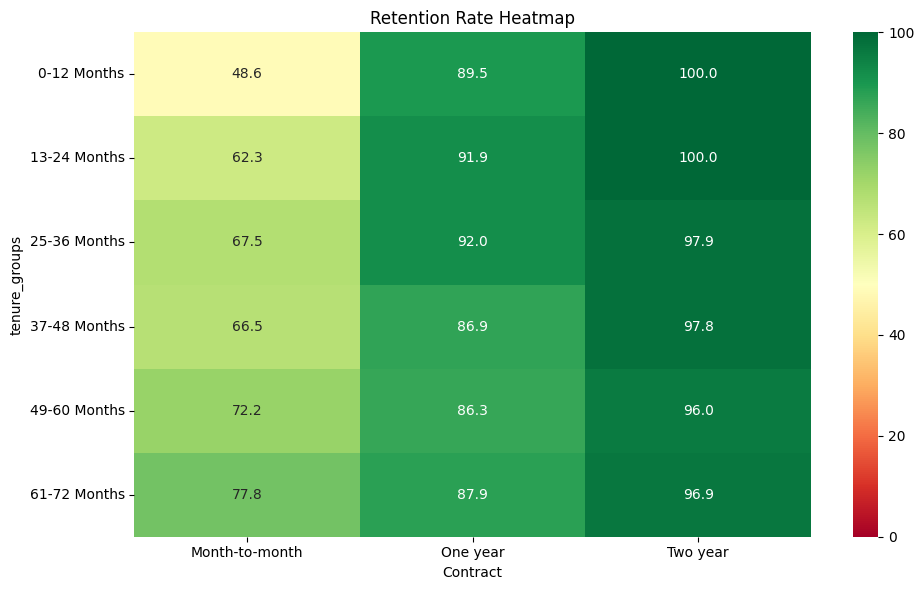

In [78]:
# Create a simple pivot table first
pivot = cohort.pivot_table(
    index='tenure_groups',
    columns='Contract',
    values='Retention_Rate'
)

# Sort rows in correct order
order = ['0-12 Months', '13-24 Months',
         '25-36 Months', '37-48 Months',
         '49-60 Months', '61-72 Months']
pivot = pivot.reindex(order)

print("Retention Rate by Tenure & Contract:")
print(pivot)

# Draw heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,           # our data
    annot=True,      # show numbers inside boxes
    fmt='.1f',       # 1 decimal place
    cmap='RdYlGn',   # Red=bad, Yellow=ok, Green=good
    vmin=0,          # minimum value = 0%
    vmax=100         # maximum value = 100%
)

plt.title('Retention Rate Heatmap')
plt.tight_layout()
plt.savefig('../Visuals/heatmap.png')
plt.show()

Churn Rate by Tenure:
tenure_groups
0-12 Months     47.44
13-24 Months    28.71
25-36 Months    21.63
37-48 Months    19.03
49-60 Months    14.42
61-72 Months     6.61
Name: churn_flag, dtype: float64


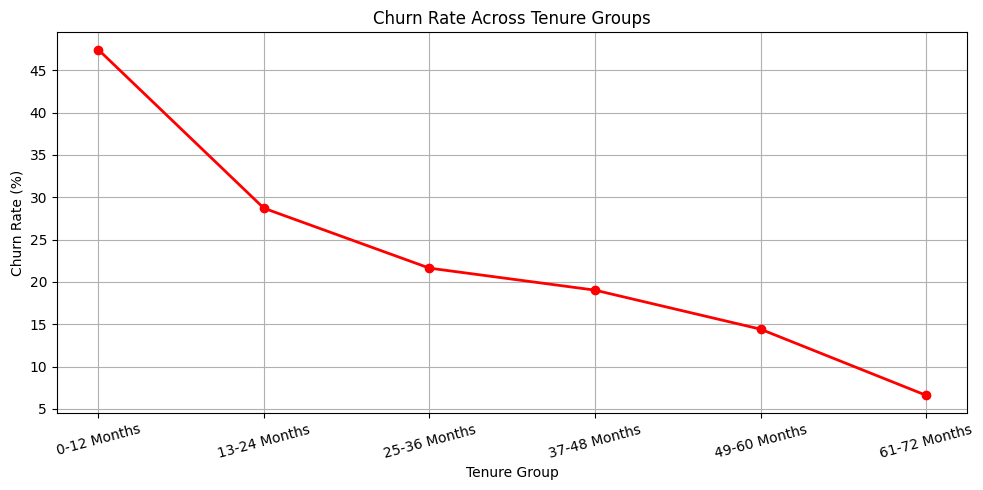

In [79]:
# Churn rate per tenure group
# Simple groupby → same as before

trend = df.groupby('tenure_groups')['churn_flag'].mean()
trend = trend * 100  # convert to percentage
trend = trend.round(2)

print("Churn Rate by Tenure:")
print(trend)

# Simple line chart
plt.figure(figsize=(10, 5))

plt.plot(
    trend.index,   # x axis = tenure groups
    trend.values,  # y axis = churn rate
    marker='o',    # circle at each point
    color='red',
    linewidth=2
)

plt.title('Churn Rate Across Tenure Groups')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.grid(True)
plt.tight_layout()
plt.savefig('../Visuals/churn_trend.png')
plt.show()

Retained per group:
tenure_groups
0-12 Months     1149
13-24 Months     730
25-36 Months     652
37-48 Months     617
49-60 Months     712
61-72 Months    1314
Name: churn_flag, dtype: int64

Churned per group:
tenure_groups
0-12 Months     1037
13-24 Months     294
25-36 Months     180
37-48 Months     145
49-60 Months     120
61-72 Months      93
Name: churn_flag, dtype: int64


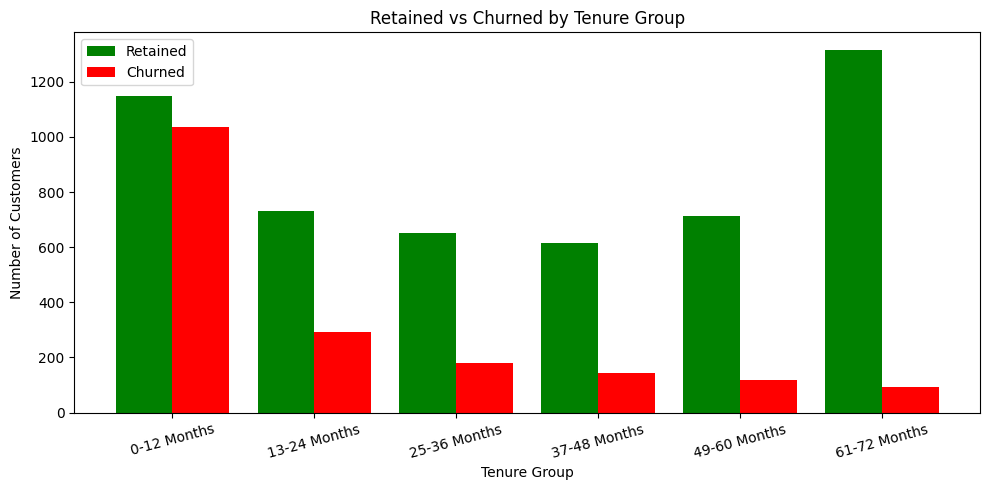

In [80]:
# Count retained and churned per tenure group
retained = df[df['churn_flag']==0].groupby(
           'tenure_groups')['churn_flag'].count()

churned  = df[df['churn_flag']==1].groupby(
           'tenure_groups')['churn_flag'].count()

print("Retained per group:")
print(retained)
print("\nChurned per group:")
print(churned)

# Simple bar chart
fig, ax = plt.subplots(figsize=(10, 5))

# Plot two bars side by side
x = range(len(retained))

ax.bar([i - 0.2 for i in x],
       retained.values,
       width=0.4,
       label='Retained',
       color='green')

ax.bar([i + 0.2 for i in x],
       churned.values,
       width=0.4,
       label='Churned',
       color='red')

ax.set_xticks(x)
ax.set_xticklabels(retained.index, rotation=15)
ax.set_title('Retained vs Churned by Tenure Group')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig('../Visuals/retained_vs_churned.png')
plt.show()

In [ ]:
# Save cohort table for Power BI
cohort.to_csv('../Data/cohort_analysis.csv', index=False)
print("Cohort data saved!")

# Print simple summary
print("\n" + "="*40)
print("COHORT SUMMARY")
print("="*40)

# Highest churn combination
worst = cohort.loc[cohort['churned_Rate'].idxmax()]
print(f"\nHighest Churn:")
print(f"Tenure   : {worst['tenure_groups']}")
print(f"Contract : {worst['Contract']}")
print(f"Churn    : {worst['churned_Rate']}%")

# Lowest churn combination
best = cohort.loc[cohort['churned_Rate'].idxmin()]
print(f"\nLowest Churn:")
print(f"Tenure   : {best['tenure_groups']}")
print(f"Contract : {best['Contract']}")
print(f"Churn    : {best['churned_Rate']}%")
print("="*40)

Cohort data saved!

COHORT SUMMARY

Highest Churn:
Tenure   : 0-12 Months
Contract : Month-to-month
Churn    : 51.35%

Lowest Churn:
Tenure   : 0-12 Months
Contract : Two year
Churn    : 0.0%
